# Day 4 — EDA Part 1: Distributions & Outliers

## Step 1:

In [91]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [92]:
penguin = pd.read_csv("penguins.csv")
print(penguin.isnull().sum())
print(penguin.shape)

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64
(344, 8)


- There is a total of 11/ 344 rows with N/A data.
- Those rows will be removed in order to have a clean data set.

In [83]:
bill_length_mean = penguin["bill_length_mm"].mean().round()
print("Bill length mean:", bill_length_mean)
penguin["bill_length_mm"] = penguin["bill_length_mm"].fillna(bill_length_mean)

bill_depth_mean = penguin["bill_depth_mm"].mean().round()
print("Bill depth mean:", bill_depth_mean)
penguin["bill_depth_mm"] = penguin["bill_depth_mm"].fillna(bill_depth_mean)

flipper_length_mean = penguin["flipper_length_mm"].mean().round()
print("Flipper length mean:", flipper_length_mean)
penguin["flipper_length_mm"] = penguin["flipper_length_mm"].fillna(flipper_length_mean)

body_mass_mean = penguin["body_mass_g"].mean().round()
print("Bill length mean:", body_mass_mean)
penguin["body_mass_g"] = penguin["body_mass_g"].fillna(body_mass_mean)

Bill length mean: 44.0
Bill depth mean: 17.0
Flipper length mean: 201.0
Bill length mean: 4202.0


All rows with 2 missing values were filled with the mean value of the respective column.

In [84]:
penguins = penguin.dropna(subset=["sex"])
print(penguins.isnull().sum())
print(penguins.shape)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64
(333, 8)


Rows with missing sex data were dropped.

penguins.duplicated().sum()


No duplicate rows detected.

In [86]:
penguins.nunique()

species                3
island                 3
bill_length_mm       163
bill_depth_mm         79
flipper_length_mm     54
body_mass_g           93
sex                    2
year                   3
dtype: int64

Numbers of unique values per row listed above.

In [87]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


Above is the final cleaned dataset.

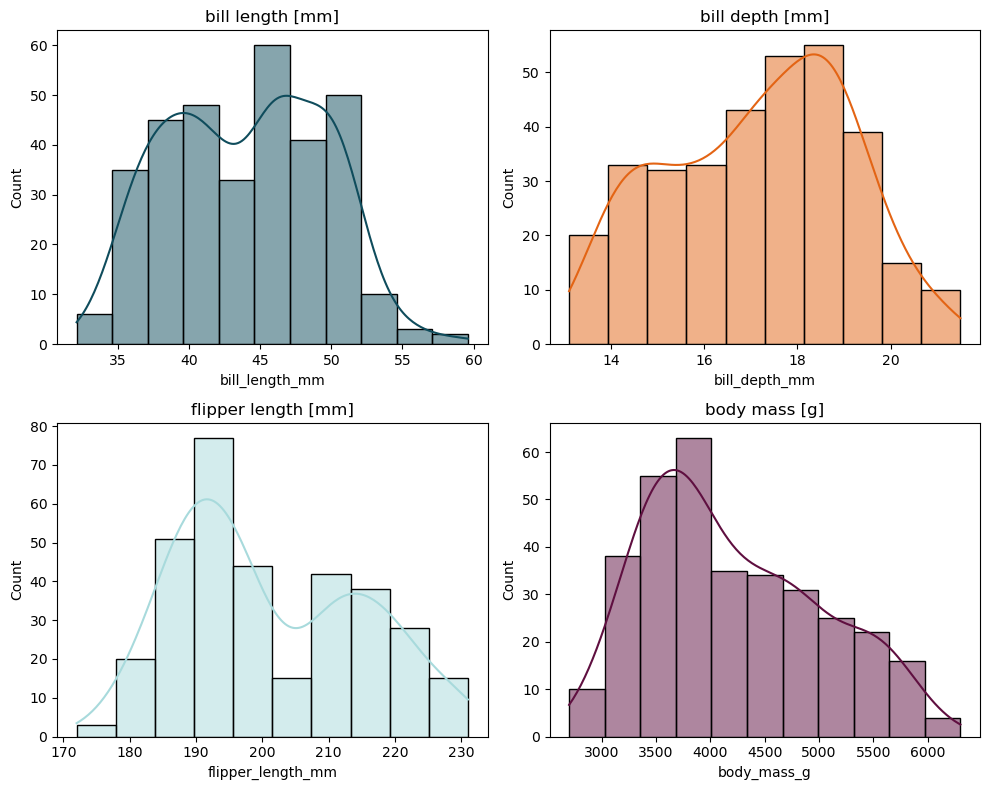

In [90]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.histplot(penguins["bill_length_mm"], kde= True, ax=axes[0,0], color="#0f4c5c")
sns.histplot(penguins["bill_depth_mm"], kde= True, ax=axes[0,1], color="#e36414")
sns.histplot(penguins["flipper_length_mm"], kde= True, ax=axes[1,0], color="#a8dadc")
sns.histplot(penguins["body_mass_g"], kde= True, ax=axes[1,1], color="#5f0f40")

axes[0,0].set_title("bill length [mm]")
axes[0,1].set_title("bill depth [mm]")
axes[1,0].set_title("flipper length [mm]")
axes[1,1].set_title("body mass [g]")

plt.tight_layout()
plt.show()

- Analysis:
  - Bill lenght: bimodal distribution, nearly symmetric.
  - Bill depth: Nearly symmetric.
  - Flipper length: mild right skew, bimodal.
  - Body mass: rigth skew towards heavier weigth pinguens.

# Step 2:

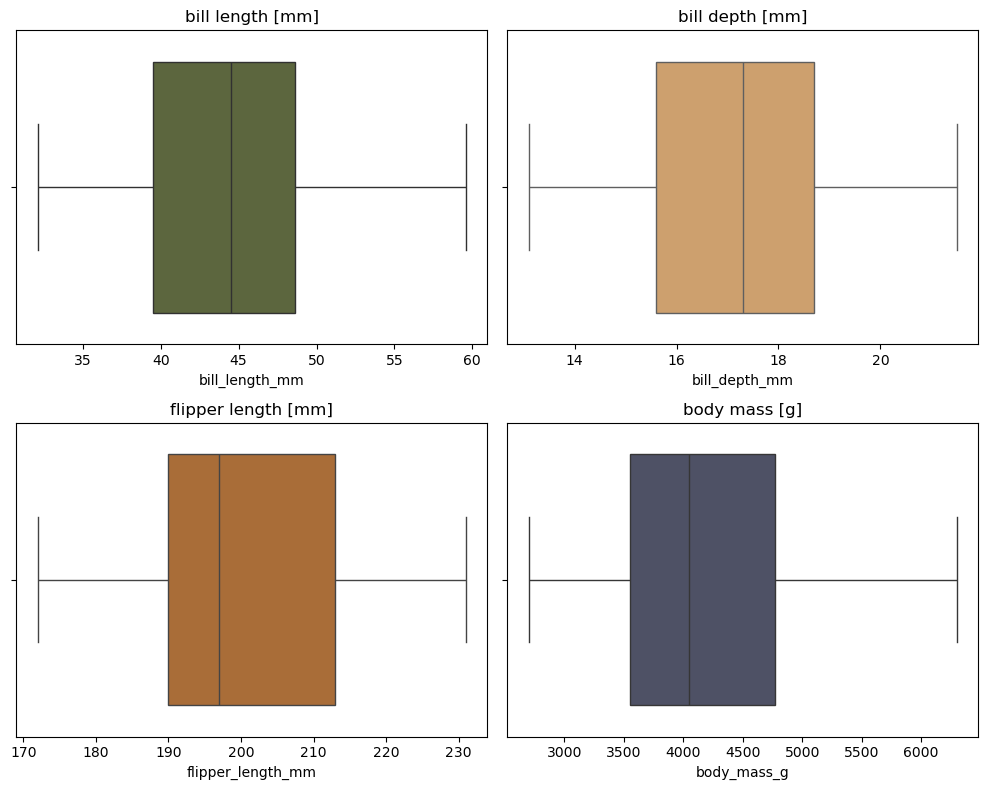

In [80]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.boxplot(x = penguins["bill_length_mm"], ax=axes[0,0], color="#606c38")
sns.boxplot(x = penguins["bill_depth_mm"], ax=axes[0,1], color="#dda15e")
sns.boxplot(x = penguins["flipper_length_mm"],  ax=axes[1,0], color="#bc6c25")
sns.boxplot(x = penguins["body_mass_g"],  ax=axes[1,1], color="#4a4e69")

axes[0,0].set_title("bill length [mm]")
axes[0,1].set_title("bill depth [mm]")
axes[1,0].set_title("flipper length [mm]")
axes[1,1].set_title("body mass [g]")

plt.tight_layout()
plt.show()

- No outliers exist, the rigth skew in flipper length and body mass are caused by realistic values.

# Step 3:

In [68]:
Q1 = penguins["flipper_length_mm"].quantile(0.25)
Q3 = penguins["flipper_length_mm"].quantile(0.75)
IQR = Q3 - Q1
outliers_f = penguins[(penguins["flipper_length_mm"] < Q1 - 1.5*IQR) | (penguins["flipper_length_mm"] > Q3 + 1.5*IQR)]

print("Number of outliers:", len(outliers_f))

Number of outliers: 0
Empty DataFrame
Columns: [species, flipper_length_mm]
Index: []


In [67]:
Q1 = penguins["body_mass_g"].quantile(0.25)
Q3 = penguins["body_mass_g"].quantile(0.75)
IQR = Q3 - Q1
outliers_b = penguins[(penguins["body_mass_g"] < Q1 - 1.5*IQR) | (penguins["body_mass_g"] > Q3 + 1.5*IQR)]

print("Number of outliers:", len(outliers_b))

Number of outliers: 0


- Results of IQR method for detecting outliers:
  - Zero outliers were detected fro both, penguins' body mass and flipper lenghts.
  - The right skew was caused byy Gentoo penguins being realisticly heavier tha the other two species.
  - For the above reasons no further modifications were performed on the data.

# Step 4:

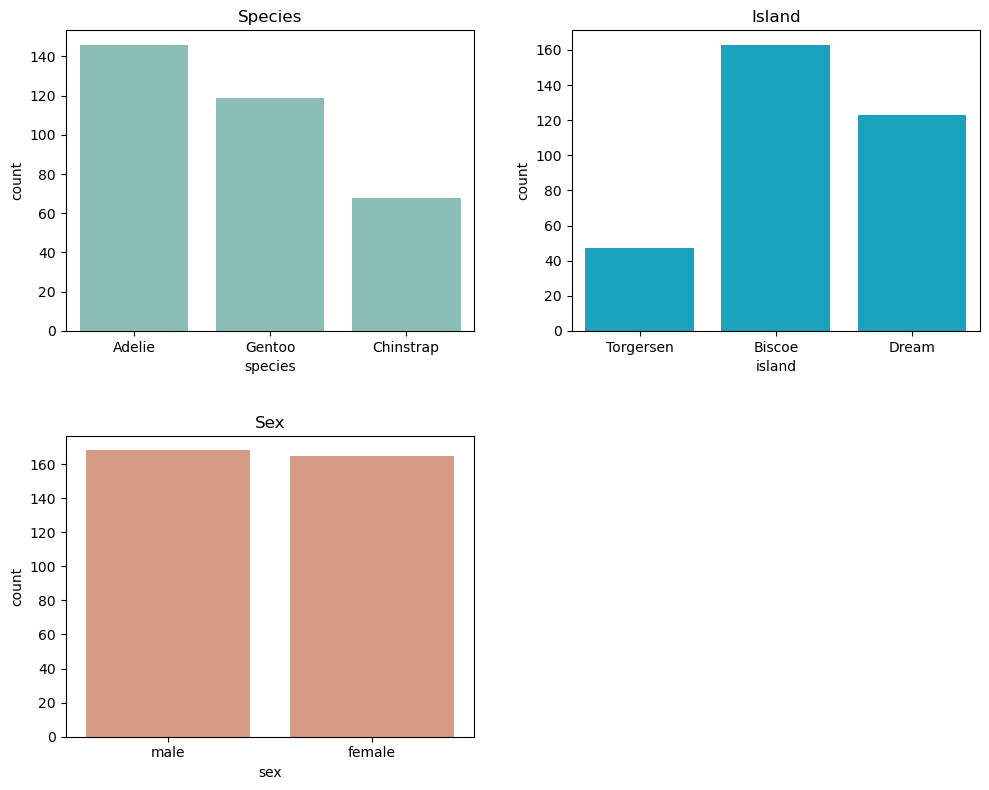

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.countplot(data=penguins, x="species", ax=axes[0,0], color="#83c5be")
sns.countplot(data=penguins, x="island", ax=axes[0,1], color="#00b4d8")
sns.countplot(data=penguins, x="sex", ax=axes[1,0], color = "#e29578")

axes[0,0].set_title("Species")
axes[0,1].set_title("Island")
axes[1,0].set_title("Sex")

fig.delaxes(axes[1, 1])

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()

- Analysis:
    - Species: Chinstrap has the loswest amount of birds - around 65 - while Adelie species has the most amount of birds - slightly over 140.
    - Island: Torgersen island has a relatively low bird population in comparison to other islands.
    - Sex: equal distribution of birds accross both genders.  